In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive (3).zip


In [ ]:
print(uploaded.keys())

dict_keys(['archive (3).zip'])


In [ ]:
import io, zipfile
import pandas as pd
import numpy as np

# ── Auto-detect the uploaded filename ────────────────────────────────────────
print("Uploaded files:", list(uploaded.keys()))

zip_filename = list(uploaded.keys())[0]  # picks whatever file you uploaded
print(f"Using file: {zip_filename}")

# ── Unzip and read CSV ────────────────────────────────────────────────────────
zip_bytes = io.BytesIO(uploaded[zip_filename])

with zipfile.ZipFile(zip_bytes) as z:
    print("Files inside zip:", z.namelist())   # shows all files in the zip
    csv_filename = [f for f in z.namelist() if f.endswith('.csv')][0]
    print(f"Reading CSV: {csv_filename}")

    with z.open(csv_filename) as f:
        df = pd.read_csv(f, parse_dates=['Date'])

print("✅ Data loaded!")
print("Shape:", df.shape)
df.head()

Uploaded files: ['archive (3).zip']
Using file: archive (3).zip
Files inside zip: ['household_energy_consumption.csv']
Reading CSV: household_energy_consumption.csv
✅ Data loaded!
Shape: (90000, 7)


,Household_ID,Date,Energy_Consumption_kWh,Household_Size,Avg_Temperature_C,Has_AC,Peak_Hours_Usage_kWh
0,H00001,2025-04-01,8.4,4,17.8,No,3.2
1,H00001,2025-04-02,7.9,4,17.3,No,2.8
2,H00001,2025-04-03,9.2,4,18.6,No,3.0
3,H00001,2025-04-04,7.9,4,18.2,No,2.7
4,H00001,2025-04-05,9.6,4,11.9,No,3.2


In [ ]:
# ══════════════════════════════════════════════════════
# PREPROCESSING
# ══════════════════════════════════════════════════════

# 1. Missing values
num_cols = df.select_dtypes(include='number').columns
cat_cols = df.select_dtypes(include='object').columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("✅ Missing values handled:", df.isnull().sum().sum(), "remaining")

# 2. Remove duplicates
before = len(df)
df.drop_duplicates(inplace=True)
print(f"✅ Duplicates removed: {before - len(df)}")

# 3. Outlier capping (IQR Winsorization)
for col in ['Energy_Consumption_kWh', 'Avg_Temperature_C', 'Peak_Hours_Usage_kWh']:
    if col in df.columns:
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        df[col] = df[col].clip(lower=Q1 - 1.5*IQR, upper=Q3 + 1.5*IQR)
print("✅ Outliers capped (IQR Winsorization)")

# 4. Encode Has_AC
df['Has_AC_num'] = (df['Has_AC'] == 'Yes').astype(int)
print("✅ Has_AC encoded: Yes=1, No=0")

# 5. Date features
if 'Date' in df.columns:
    df['Month']     = df['Date'].dt.month
    df['DayOfWeek'] = df['Date'].dt.dayofweek
    df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)
    print("✅ Date features extracted: Month, DayOfWeek, IsWeekend")

print("\n✅ Preprocessing complete! Shape:", df.shape)
df.head()

✅ Missing values handled: 0 remaining
✅ Duplicates removed: 0
✅ Outliers capped (IQR Winsorization)
✅ Has_AC encoded: Yes=1, No=0
✅ Date features extracted: Month, DayOfWeek, IsWeekend

✅ Preprocessing complete! Shape: (90000, 11)


,Household_ID,Date,Energy_Consumption_kWh,Household_Size,Avg_Temperature_C,Has_AC,Peak_Hours_Usage_kWh,Has_AC_num,Month,DayOfWeek,IsWeekend
0,H00001,2025-04-01,8.4,4,17.8,No,3.2,0,4,1,0
1,H00001,2025-04-02,7.9,4,17.3,No,2.8,0,4,2,0
2,H00001,2025-04-03,9.2,4,18.6,No,3.0,0,4,3,0
3,H00001,2025-04-04,7.9,4,18.2,No,2.7,0,4,4,0
4,H00001,2025-04-05,9.6,4,11.9,No,3.2,0,4,5,1


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve, auc
)

print("✅ All libraries ready!")

✅ All libraries ready!


In [ ]:
print("Shape:", df.shape)
print()
print("Column names:", df.columns.tolist())
print()
print("Data types:\n", df.dtypes)
print()
print("Missing values:\n", df.isnull().sum())
print()
df.describe()

Shape: (90000, 11)

Column names: ['Household_ID', 'Date', 'Energy_Consumption_kWh', 'Household_Size', 'Avg_Temperature_C', 'Has_AC', 'Peak_Hours_Usage_kWh', 'Has_AC_num', 'Month', 'DayOfWeek', 'IsWeekend']

Data types:
 Household_ID                      object
Date                      datetime64[ns]
Energy_Consumption_kWh           float64
Household_Size                     int64
Avg_Temperature_C                float64
Has_AC                            object
Peak_Hours_Usage_kWh             float64
Has_AC_num                         int64
Month                              int32
DayOfWeek                          int32
IsWeekend                          int64
dtype: object

Missing values:
 Household_ID              0
Date                      0
Energy_Consumption_kWh    0
Household_Size            0
Avg_Temperature_C         0
Has_AC                    0
Peak_Hours_Usage_kWh      0
Has_AC_num                0
Month                     0
DayOfWeek                 0
IsWeekend       

,Date,Energy_Consumption_kWh,Household_Size,Avg_Temperature_C,Peak_Hours_Usage_kWh,Has_AC_num,Month,DayOfWeek,IsWeekend
count,90000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.0,90000.000000,90000.000000
mean,2025-04-04 00:00:03.840000256,10.571988,3.487811,17.505978,4.319557,0.494356,4.0,2.999978,0.285711
min,2025-04-01 00:00:00,0.500000,1.000000,10.700000,0.200000,0.000000,4.0,0.000000,0.000000
25%,2025-04-02 00:00:00,6.000000,2.000000,15.800000,2.300000,0.000000,4.0,1.000000,0.000000
50%,2025-04-04 00:00:00,10.400000,3.000000,17.500000,4.000000,0.000000,4.0,3.000000,0.000000
75%,2025-04-06 00:00:00,14.800000,5.000000,19.200000,6.000000,1.000000,4.0,5.000000,1.000000
max,2025-04-08 00:00:00,20.000000,6.000000,24.300000,10.000000,1.000000,4.0,6.000000,1.000000
std,NaN,5.519494,1.709761,2.483032,2.531432,0.499971,0.0,2.000011,0.451755


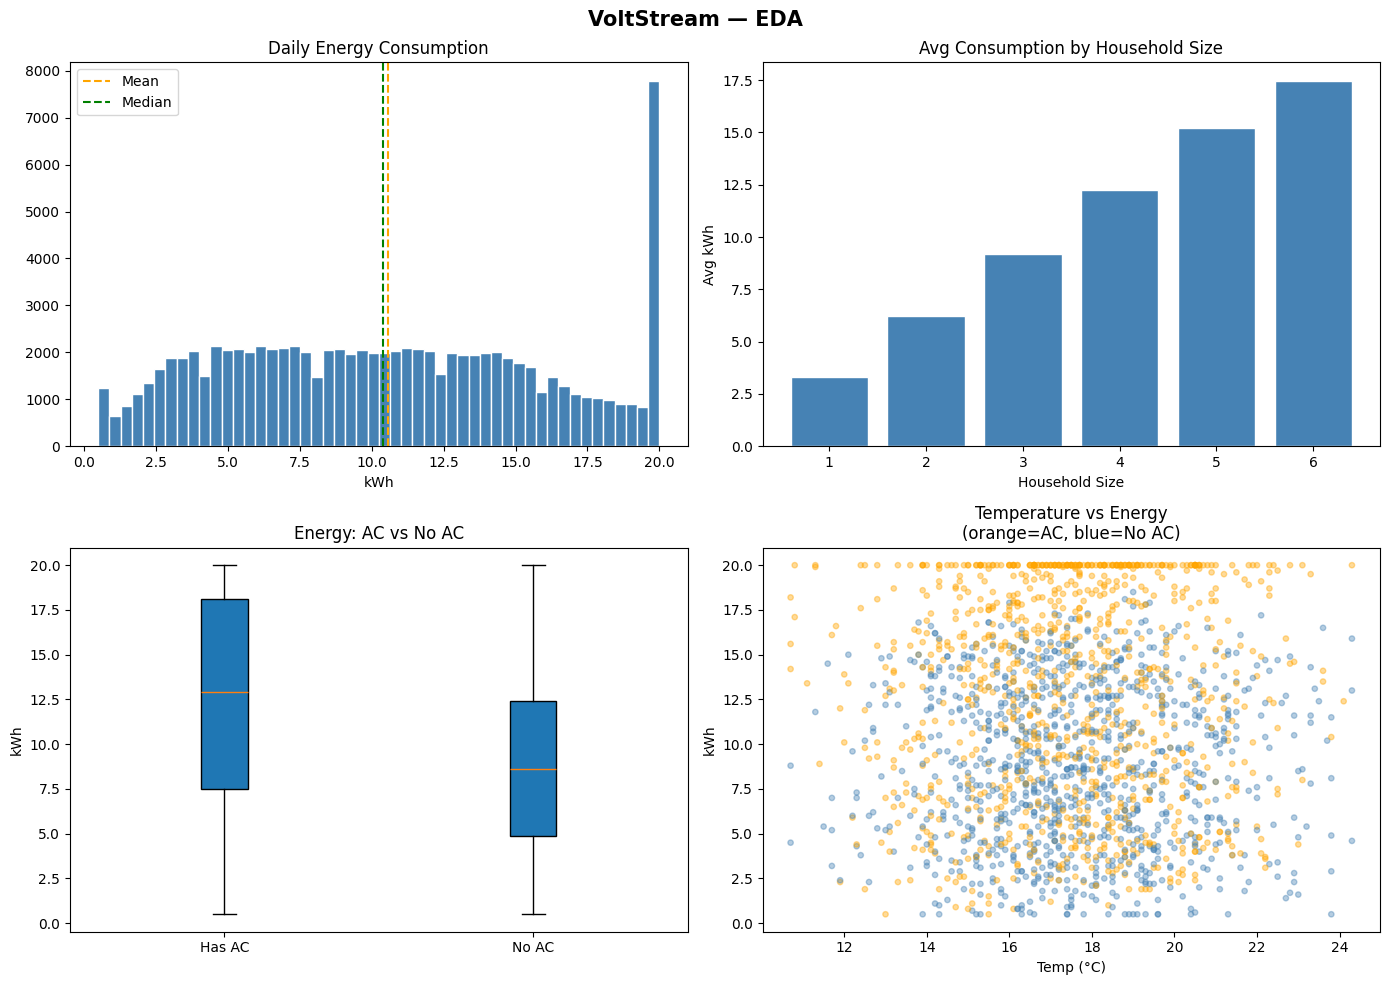

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('VoltStream — EDA', fontsize=15, fontweight='bold')

# Plot 1: Energy distribution
axes[0,0].hist(df['Energy_Consumption_kWh'], bins=50, color='steelblue', edgecolor='white')
axes[0,0].axvline(df['Energy_Consumption_kWh'].mean(), color='orange', linestyle='--', label='Mean')
axes[0,0].axvline(df['Energy_Consumption_kWh'].median(), color='green', linestyle='--', label='Median')
axes[0,0].set_title('Daily Energy Consumption')
axes[0,0].set_xlabel('kWh')
axes[0,0].legend()

# Plot 2: Usage by household size
size_avg = df.groupby('Household_Size')['Energy_Consumption_kWh'].mean()
axes[0,1].bar(size_avg.index, size_avg.values, color='steelblue', edgecolor='white')
axes[0,1].set_title('Avg Consumption by Household Size')
axes[0,1].set_xlabel('Household Size')
axes[0,1].set_ylabel('Avg kWh')

# Plot 3: AC vs No AC
ac_yes = df[df['Has_AC']=='Yes']['Energy_Consumption_kWh']
ac_no  = df[df['Has_AC']=='No']['Energy_Consumption_kWh']
axes[1,0].boxplot([ac_yes, ac_no], labels=['Has AC', 'No AC'], patch_artist=True)
axes[1,0].set_title('Energy: AC vs No AC')
axes[1,0].set_ylabel('kWh')

# Plot 4: Temperature vs Energy
sample = df.sample(2000, random_state=42)
colors = ['orange' if ac=='Yes' else 'steelblue' for ac in sample['Has_AC']]
axes[1,1].scatter(sample['Avg_Temperature_C'], sample['Energy_Consumption_kWh'],
                  c=colors, alpha=0.4, s=15)
axes[1,1].set_title('Temperature vs Energy\n(orange=AC, blue=No AC)')
axes[1,1].set_xlabel('Temp (°C)')
axes[1,1].set_ylabel('kWh')

plt.tight_layout()
plt.show()

In [ ]:
# Encode Has_AC as number
df['Has_AC_num'] = (df['Has_AC'] == 'Yes').astype(int)

# One row per household
household = df.groupby('Household_ID').agg(
    mean_consumption = ('Energy_Consumption_kWh', 'mean'),
    std_consumption  = ('Energy_Consumption_kWh', 'std'),
    mean_temp        = ('Avg_Temperature_C', 'mean'),
    household_size   = ('Household_Size', 'first'),
    has_ac           = ('Has_AC_num', 'first'),
    mean_peak        = ('Peak_Hours_Usage_kWh', 'mean'),
).reset_index()

# Regression target: monthly bill
household['monthly_bill_kwh'] = household['mean_consumption'] * 30

# Classification target: high vs low usage
THRESHOLD = household['mean_consumption'].median()
household['high_usage'] = (household['mean_consumption'] > THRESHOLD).astype(int)

print("✅ Features ready!")
print("Households:", len(household))
print("Threshold:", round(THRESHOLD, 2), "kWh/day")
household.head()

✅ Features ready!
Households: 12857
Threshold: 10.46 kWh/day


,Household_ID,mean_consumption,std_consumption,mean_temp,household_size,has_ac,mean_peak,monthly_bill_kwh,high_usage
0,H00001,8.514286,0.794625,16.742857,4,0,2.985714,255.428571,0
1,H00002,12.485714,1.337197,18.257143,5,0,4.500000,374.571429,1
2,H00003,7.657143,0.816205,16.828571,3,0,2.685714,229.714286,0
3,H00004,17.971429,1.312395,16.942857,5,1,8.085714,539.142857,1
4,H00005,13.242857,1.164556,18.000000,5,0,4.414286,397.285714,1


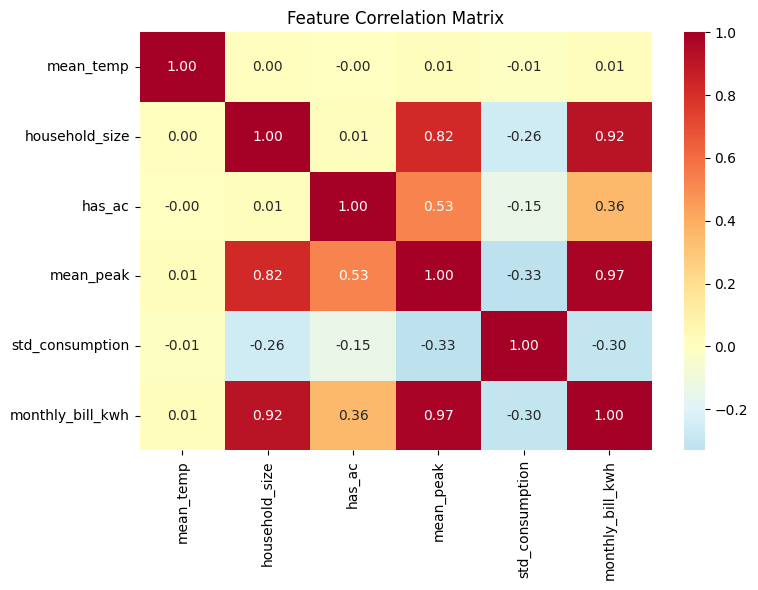

In [ ]:
cols = ['mean_temp','household_size','has_ac','mean_peak','std_consumption','monthly_bill_kwh']

plt.figure(figsize=(8, 6))
sns.heatmap(household[cols].corr(), annot=True, fmt='.2f', cmap='RdYlBu_r', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

✅ Scalers ready!
Linear Regression — 5-Fold CV R²:
  Fold 1: 0.9961
  Fold 2: 0.9963
  Fold 3: 0.9964
  Fold 4: 0.9963
  Fold 5: 0.9964
  Average: 0.9963

Logistic Regression — 5-Fold CV Accuracy:
  Fold 1: 98.41%
  Fold 2: 98.17%
  Fold 3: 97.86%
  Fold 4: 98.02%
  Fold 5: 98.25%
  Average: 98.14%


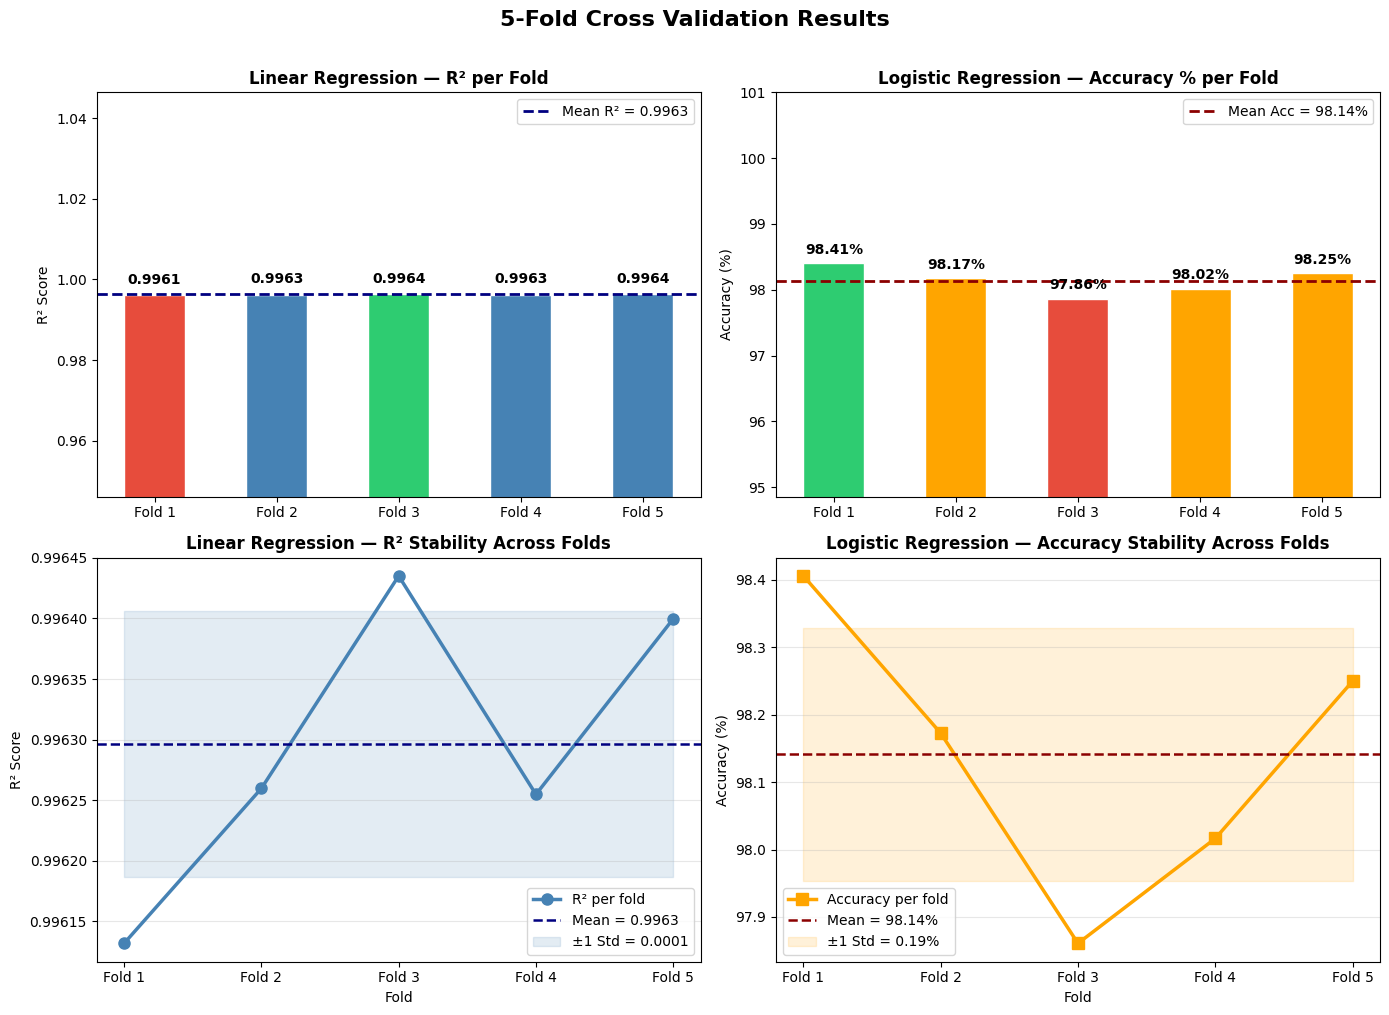

        CROSS VALIDATION SUMMARY
  Linear Regression  →  Mean R²  : 0.9963  ±  0.0001
  Logistic Regression → Mean Acc : 98.14%  ±  0.19%


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

# ── Recreate scaler2 and X2, y2 if not already defined ───────────────────────
FEATURES = ['mean_temp', 'household_size', 'has_ac', 'mean_peak', 'std_consumption']

X  = household[FEATURES]
y  = household['monthly_bill_kwh']

X2 = household[FEATURES]
y2 = household['high_usage']

scaler  = StandardScaler()
scaler2 = StandardScaler()

scaler.fit(X)
scaler2.fit(X2)

print("✅ Scalers ready!")

# ── Run Cross Validation ──────────────────────────────────────────────────────
cv_r2  = cross_val_score(LinearRegression(),
                          scaler.transform(X), y, cv=5, scoring='r2')

cv_acc = cross_val_score(LogisticRegression(max_iter=1000),
                          scaler2.transform(X2), y2, cv=5)

print("Linear Regression — 5-Fold CV R²:")
for i, s in enumerate(cv_r2, 1):
    print(f"  Fold {i}: {s:.4f}")
print(f"  Average: {cv_r2.mean():.4f}")

print()
print("Logistic Regression — 5-Fold CV Accuracy:")
for i, s in enumerate(cv_acc, 1):
    print(f"  Fold {i}: {s*100:.2f}%")
print(f"  Average: {cv_acc.mean()*100:.2f}%")

# ── Visualizations ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('5-Fold Cross Validation Results', fontsize=16, fontweight='bold', y=1.01)

folds = [f'Fold {i}' for i in range(1, 6)]
colors_r2  = ['#e74c3c' if v == cv_r2.min()  else ('#2ecc71' if v == cv_r2.max()  else 'steelblue') for v in cv_r2]
colors_acc = ['#e74c3c' if v == cv_acc.min() else ('#2ecc71' if v == cv_acc.max() else 'orange')    for v in cv_acc]

bars = axes[0, 0].bar(folds, cv_r2, color=colors_r2, edgecolor='white', width=0.5)
axes[0, 0].axhline(cv_r2.mean(), color='navy', linestyle='--', lw=2,
                    label=f'Mean R² = {cv_r2.mean():.4f}')
axes[0, 0].set_title('Linear Regression — R² per Fold', fontweight='bold')
axes[0, 0].set_ylabel('R² Score')
axes[0, 0].set_ylim(max(0, cv_r2.min() - 0.05), min(1.05, cv_r2.max() + 0.05))
axes[0, 0].legend()
for bar, val in zip(bars, cv_r2):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                     f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

bars2 = axes[0, 1].bar(folds, cv_acc * 100, color=colors_acc, edgecolor='white', width=0.5)
axes[0, 1].axhline(cv_acc.mean() * 100, color='darkred', linestyle='--', lw=2,
                    label=f'Mean Acc = {cv_acc.mean()*100:.2f}%')
axes[0, 1].set_title('Logistic Regression — Accuracy % per Fold', fontweight='bold')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].set_ylim(max(0, cv_acc.min()*100 - 3), min(101, cv_acc.max()*100 + 3))
axes[0, 1].legend()
for bar, val in zip(bars2, cv_acc):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                     f'{val*100:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

x = np.arange(1, 6)
axes[1, 0].plot(x, cv_r2, marker='o', color='steelblue', lw=2.5, ms=8, label='R² per fold')
axes[1, 0].axhline(cv_r2.mean(), color='navy', linestyle='--', lw=1.8,
                    label=f'Mean = {cv_r2.mean():.4f}')
axes[1, 0].fill_between(x, cv_r2.mean() - cv_r2.std(), cv_r2.mean() + cv_r2.std(),
                          alpha=0.15, color='steelblue', label=f'±1 Std = {cv_r2.std():.4f}')
axes[1, 0].set_title('Linear Regression — R² Stability Across Folds', fontweight='bold')
axes[1, 0].set_xlabel('Fold')
axes[1, 0].set_ylabel('R² Score')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(folds)
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

axes[1, 1].plot(x, cv_acc * 100, marker='s', color='orange', lw=2.5, ms=8, label='Accuracy per fold')
axes[1, 1].axhline(cv_acc.mean() * 100, color='darkred', linestyle='--', lw=1.8,
                    label=f'Mean = {cv_acc.mean()*100:.2f}%')
axes[1, 1].fill_between(x, (cv_acc.mean() - cv_acc.std()) * 100, (cv_acc.mean() + cv_acc.std()) * 100,
                          alpha=0.15, color='orange', label=f'±1 Std = {cv_acc.std()*100:.2f}%')
axes[1, 1].set_title('Logistic Regression — Accuracy Stability Across Folds', fontweight='bold')
axes[1, 1].set_xlabel('Fold')
axes[1, 1].set_ylabel('Accuracy (%)')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(folds)
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("=" * 45)
print("        CROSS VALIDATION SUMMARY")
print("=" * 45)
print(f"  Linear Regression  →  Mean R²  : {cv_r2.mean():.4f}  ±  {cv_r2.std():.4f}")
print(f"  Logistic Regression → Mean Acc : {cv_acc.mean()*100:.2f}%  ±  {cv_acc.std()*100:.2f}%")
print("=" * 45)

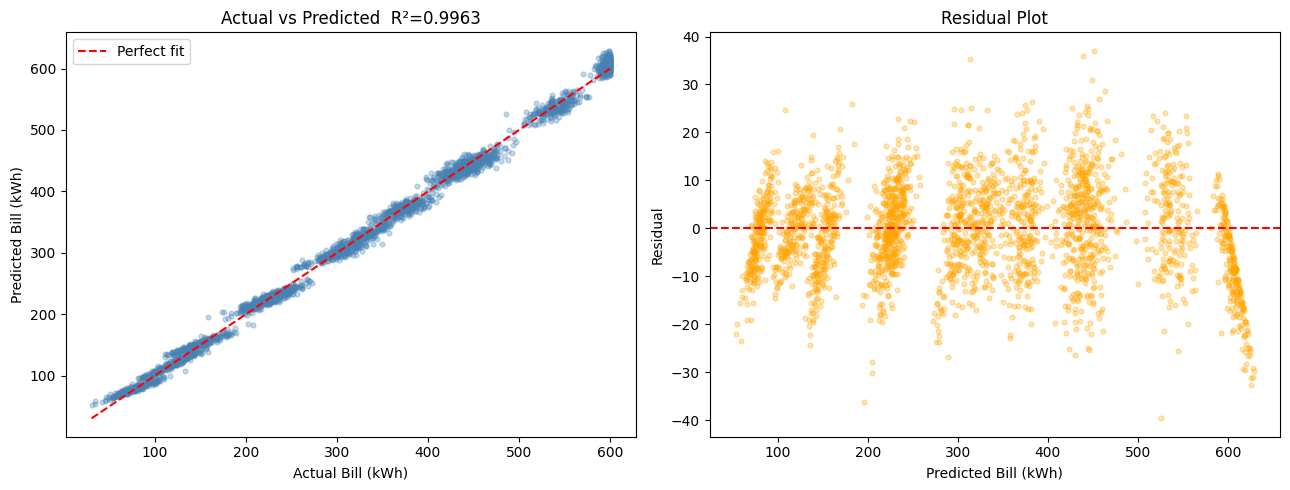

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.3, color='steelblue', s=12)
mn, mx = y_test.min(), y_test.max()
axes[0].plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='Perfect fit')
axes[0].set_xlabel('Actual Bill (kWh)')
axes[0].set_ylabel('Predicted Bill (kWh)')
axes[0].set_title(f'Actual vs Predicted  R²={r2_score(y_test, y_pred):.4f}')
axes[0].legend()

# Residuals
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.3, color='orange', s=12)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted Bill (kWh)')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()

In [ ]:
X2 = household[FEATURES]
y2 = household['high_usage']

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2)

scaler2 = StandardScaler()
X_train2_s = scaler2.fit_transform(X_train2)
X_test2_s  = scaler2.transform(X_test2)

clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train2_s, y_train2)

y_pred2 = clf.predict(X_test2_s)
y_prob2 = clf.predict_proba(X_test2_s)[:, 1]

print("✅ Logistic Regression trained!")
print(f"Accuracy: {accuracy_score(y_test2, y_pred2)*100:.2f}%")
print()
print(classification_report(y_test2, y_pred2, target_names=['Low Usage','High Usage']))

✅ Logistic Regression trained!
Accuracy: 98.29%

              precision    recall  f1-score   support

   Low Usage       0.98      0.99      0.98      1289
  High Usage       0.99      0.98      0.98      1283

    accuracy                           0.98      2572
   macro avg       0.98      0.98      0.98      2572
weighted avg       0.98      0.98      0.98      2572



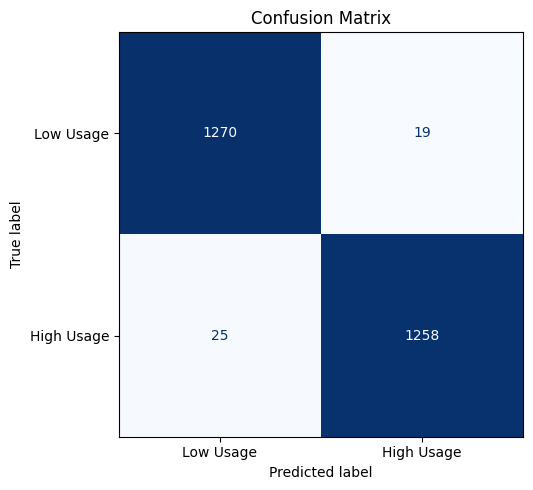

✅ Correctly said HIGH  (True Positive) : 1258
✅ Correctly said LOW   (True Negative) : 1270
❌ Said HIGH, was LOW   (False Positive): 19
❌ Said LOW,  was HIGH  (False Negative): 25


In [ ]:
cm = confusion_matrix(y_test2, y_pred2)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=['Low Usage','High Usage']).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"✅ Correctly said HIGH  (True Positive) : {tp}")
print(f"✅ Correctly said LOW   (True Negative) : {tn}")
print(f"❌ Said HIGH, was LOW   (False Positive): {fp}")
print(f"❌ Said LOW,  was HIGH  (False Negative): {fn}")

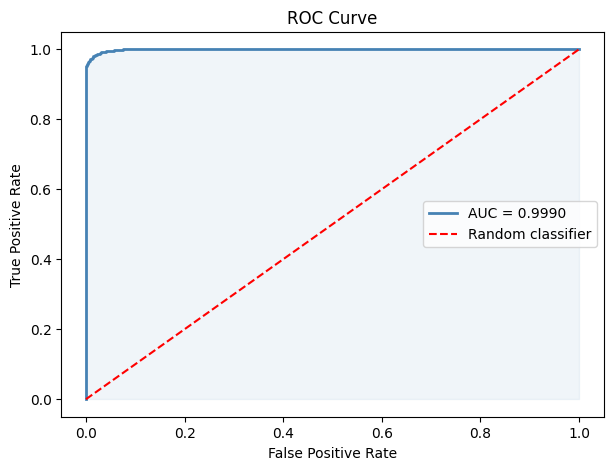

In [ ]:
fpr, tpr, _ = roc_curve(y_test2, y_prob2)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {roc_auc:.4f}')
plt.plot([0,1],[0,1],'r--', label='Random classifier')
plt.fill_between(fpr, tpr, alpha=0.08, color='steelblue')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import cross_val_score

# ── Run Cross Validation ──────────────────────────────────────────────────────
cv_r2  = cross_val_score(LinearRegression(),
                          scaler.transform(X), y, cv=5, scoring='r2')

cv_acc = cross_val_score(LogisticRegression(max_iter=1000),
                          scaler2.transform(X2), y2, cv=5)

print("Linear Regression — 5-Fold CV R²:")
for i, s in enumerate(cv_r2, 1):
    print(f"  Fold {i}: {s:.4f}")
print(f"  Average: {cv_r2.mean():.4f}")

print()
print("Logistic Regression — 5-Fold CV Accuracy:")
for i, s in enumerate(cv_acc, 1):
    print(f"  Fold {i}: {s*100:.2f}%")
print(f"  Average: {cv_acc.mean()*100:.2f}%")

# ── Visualizations ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('5-Fold Cross Validation Results', fontsize=16, fontweight='bold', y=1.01)

folds = [f'Fold {i}' for i in range(1, 6)]
colors_r2  = ['#e74c3c' if v == cv_r2.min()  else ('#2ecc71' if v == cv_r2.max()  else 'steelblue') for v in cv_r2]
colors_acc = ['#e74c3c' if v == cv_acc.min() else ('#2ecc71' if v == cv_acc.max() else 'orange')    for v in cv_acc]

# ── Plot 1: Linear Regression R² per fold (Bar) ───────────────────────────────
bars = axes[0, 0].bar(folds, cv_r2, color=colors_r2, edgecolor='white', width=0.5)
axes[0, 0].axhline(cv_r2.mean(), color='navy', linestyle='--', lw=2,
                    label=f'Mean R² = {cv_r2.mean():.4f}')
axes[0, 0].set_title('Linear Regression — R² per Fold', fontweight='bold')
axes[0, 0].set_ylabel('R² Score')
axes[0, 0].set_ylim(max(0, cv_r2.min() - 0.05), min(1.05, cv_r2.max() + 0.05))
axes[0, 0].legend()
for bar, val in zip(bars, cv_r2):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                     f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# ── Plot 2: Logistic Regression Accuracy per fold (Bar) ──────────────────────
bars2 = axes[0, 1].bar(folds, cv_acc * 100, color=colors_acc, edgecolor='white', width=0.5)
axes[0, 1].axhline(cv_acc.mean() * 100, color='darkred', linestyle='--', lw=2,
                    label=f'Mean Acc = {cv_acc.mean()*100:.2f}%')
axes[0, 1].set_title('Logistic Regression — Accuracy % per Fold', fontweight='bold')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].set_ylim(max(0, cv_acc.min()*100 - 3), min(101, cv_acc.max()*100 + 3))
axes[0, 1].legend()
for bar, val in zip(bars2, cv_acc):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                     f'{val*100:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# ── Plot 3: Linear Regression R² Line plot with std band ─────────────────────
x = np.arange(1, 6)
axes[1, 0].plot(x, cv_r2, marker='o', color='steelblue', lw=2.5, ms=8, label='R² per fold')
axes[1, 0].axhline(cv_r2.mean(), color='navy', linestyle='--', lw=1.8,
                    label=f'Mean = {cv_r2.mean():.4f}')
axes[1, 0].fill_between(x,
                          cv_r2.mean() - cv_r2.std(),
                          cv_r2.mean() + cv_r2.std(),
                          alpha=0.15, color='steelblue', label=f'±1 Std = {cv_r2.std():.4f}')
axes[1, 0].set_title('Linear Regression — R² Stability Across Folds', fontweight='bold')
axes[1, 0].set_xlabel('Fold')
axes[1, 0].set_ylabel('R² Score')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(folds)
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# ── Plot 4: Logistic Regression Accuracy Line plot with std band ──────────────
axes[1, 1].plot(x, cv_acc * 100, marker='s', color='orange', lw=2.5, ms=8, label='Accuracy per fold')
axes[1, 1].axhline(cv_acc.mean() * 100, color='darkred', linestyle='--', lw=1.8,
                    label=f'Mean = {cv_acc.mean()*100:.2f}%')
axes[1, 1].fill_between(x,
                          (cv_acc.mean() - cv_acc.std()) * 100,
                          (cv_acc.mean() + cv_acc.std()) * 100,
                          alpha=0.15, color='orange', label=f'±1 Std = {cv_acc.std()*100:.2f}%')
axes[1, 1].set_title('Logistic Regression — Accuracy Stability Across Folds', fontweight='bold')
axes[1, 1].set_xlabel('Fold')
axes[1, 1].set_ylabel('Accuracy (%)')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(folds)
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ── Summary Box ───────────────────────────────────────────────────────────────
print("=" * 45)
print("        CROSS VALIDATION SUMMARY")
print("=" * 45)
print(f"  Linear Regression  →  Mean R²  : {cv_r2.mean():.4f}  ±  {cv_r2.std():.4f}")
print(f"  Logistic Regression → Mean Acc : {cv_acc.mean()*100:.2f}%  ±  {cv_acc.std()*100:.2f}%")
print("=" * 45)

NameError: name 'scaler' is not defined

✅ Decision Tree Accuracy: 98.37%

              precision    recall  f1-score   support

         Low       0.97      0.99      0.98      1289
        High       0.99      0.97      0.98      1283

    accuracy                           0.98      2572
   macro avg       0.98      0.98      0.98      2572
weighted avg       0.98      0.98      0.98      2572



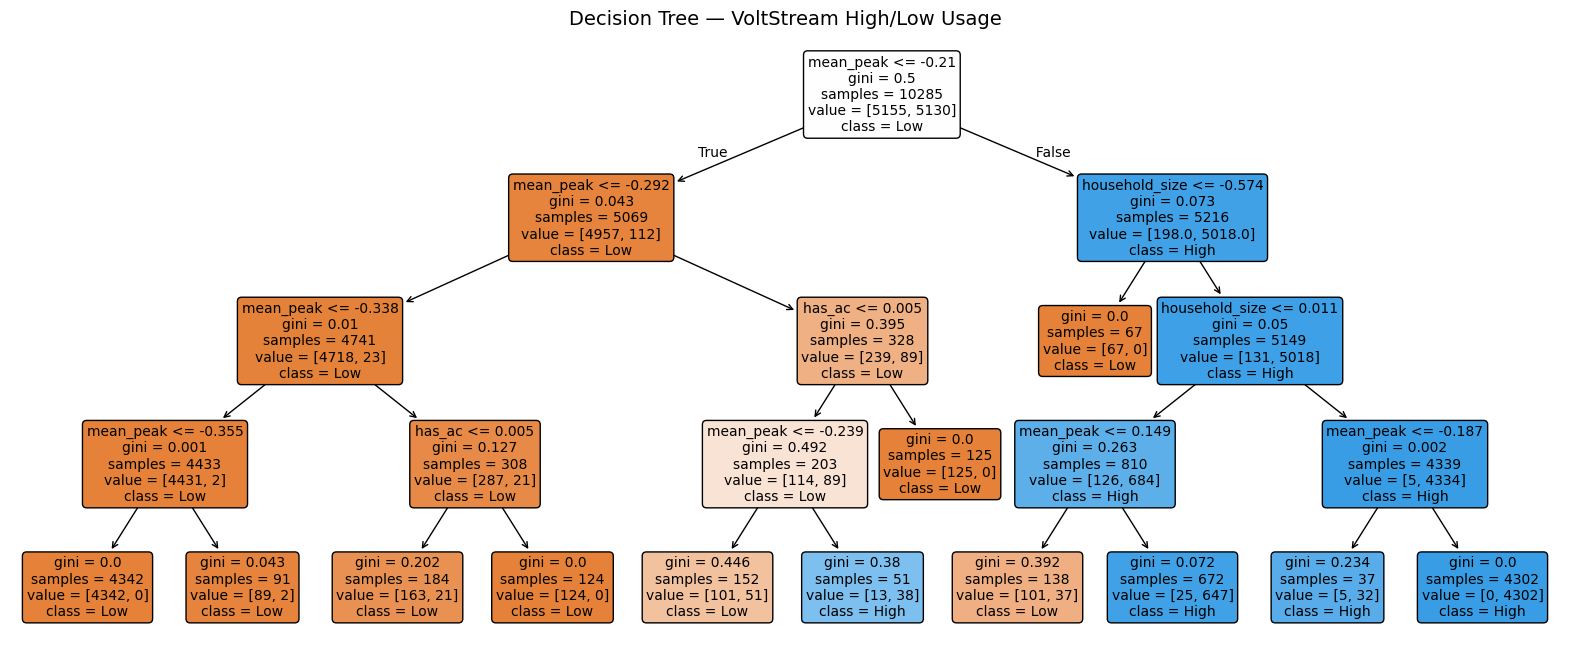

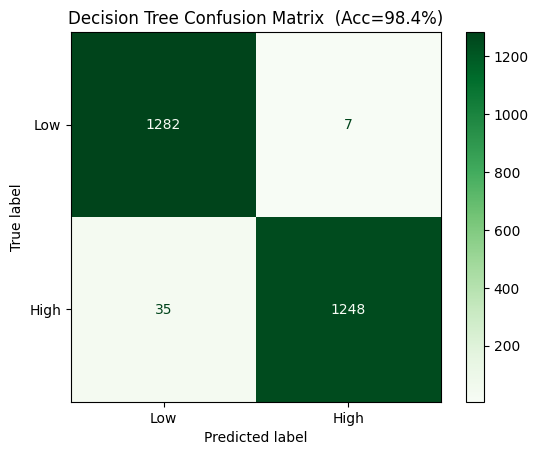

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# ── Train ────────────────────────────────────────────────────────────────────
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_model.fit(X_train2_s, y_train2)

# ── Predict ──────────────────────────────────────────────────────────────────
y_pred_dt = dt_model.predict(X_test2_s)

# ── Metrics ──────────────────────────────────────────────────────────────────
acc_dt = accuracy_score(y_test2, y_pred_dt)
print(f"✅ Decision Tree Accuracy: {acc_dt*100:.2f}%")
print()
print(classification_report(y_test2, y_pred_dt, target_names=['Low','High']))

# ── Plot the tree ─────────────────────────────────────────────────────────────
plt.figure(figsize=(20, 8))
plot_tree(dt_model, feature_names=FEATURES,
          class_names=['Low','High'],
          filled=True, rounded=True, fontsize=10)
plt.title('Decision Tree — VoltStream High/Low Usage', fontsize=14)
plt.show()

# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm_dt = confusion_matrix(y_test2, y_pred_dt)
ConfusionMatrixDisplay(cm_dt, display_labels=['Low','High']).plot(cmap='Greens')
plt.title(f'Decision Tree Confusion Matrix  (Acc={acc_dt*100:.1f}%)')
plt.show()

✅ Random Forest Accuracy: 98.41%

              precision    recall  f1-score   support

         Low       0.98      0.99      0.98      1289
        High       0.99      0.98      0.98      1283

    accuracy                           0.98      2572
   macro avg       0.98      0.98      0.98      2572
weighted avg       0.98      0.98      0.98      2572



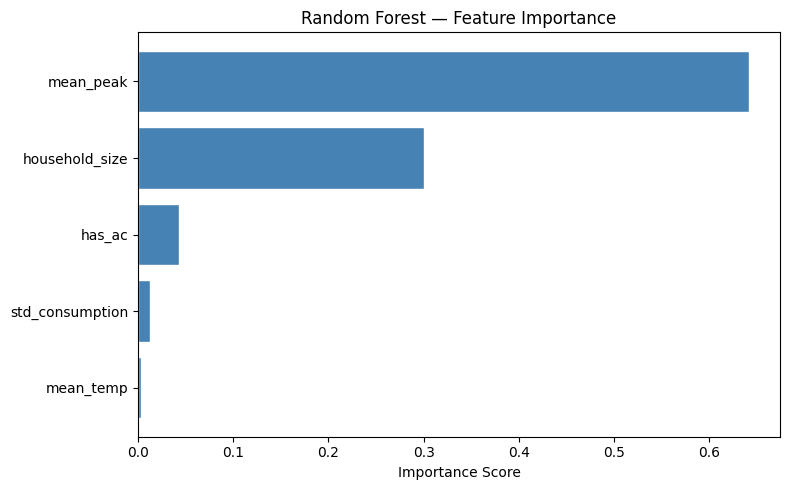

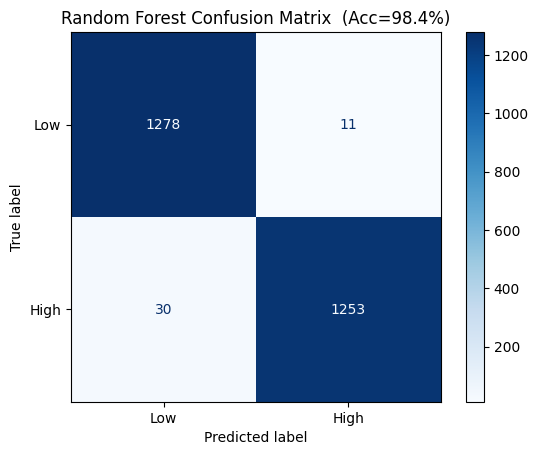

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# ── Train ─────────────────────────────────────────────────────────────────────
rf_model = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
rf_model.fit(X_train2_s, y_train2)

# ── Predict ───────────────────────────────────────────────────────────────────
y_pred_rf = rf_model.predict(X_test2_s)

# ── Metrics ───────────────────────────────────────────────────────────────────
acc_rf = accuracy_score(y_test2, y_pred_rf)
print(f"✅ Random Forest Accuracy: {acc_rf*100:.2f}%")
print()
print(classification_report(y_test2, y_pred_rf, target_names=['Low','High']))

# ── Feature Importance ────────────────────────────────────────────────────────
importances = rf_model.feature_importances_
feat_imp = pd.DataFrame({'Feature': FEATURES, 'Importance': importances})
feat_imp = feat_imp.sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(feat_imp['Feature'], feat_imp['Importance'], color='steelblue', edgecolor='white')
plt.title('Random Forest — Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm_rf = confusion_matrix(y_test2, y_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=['Low','High']).plot(cmap='Blues')
plt.title(f'Random Forest Confusion Matrix  (Acc={acc_rf*100:.1f}%)')
plt.show()

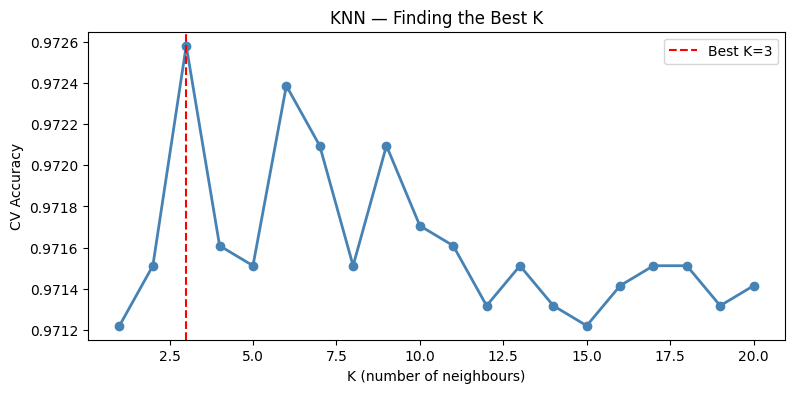

✅ KNN Accuracy (K=3): 97.47%

              precision    recall  f1-score   support

         Low       0.97      0.98      0.97      1289
        High       0.98      0.97      0.97      1283

    accuracy                           0.97      2572
   macro avg       0.97      0.97      0.97      2572
weighted avg       0.97      0.97      0.97      2572



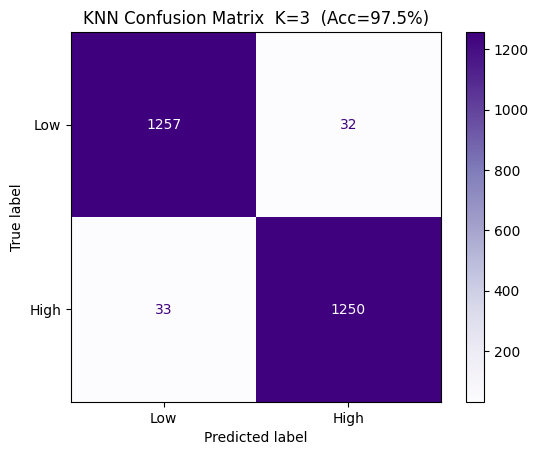

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# ── Find best K ───────────────────────────────────────────────────────────────
k_scores = []
k_values = range(1, 21)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    score = cross_val_score(knn, X_train2_s, y_train2, cv=5).mean()
    k_scores.append(score)

# Plot K vs Accuracy
plt.figure(figsize=(9, 4))
plt.plot(k_values, k_scores, marker='o', color='steelblue', lw=2)
plt.axvline(k_values[k_scores.index(max(k_scores))],
            color='red', linestyle='--', label=f'Best K={k_values[k_scores.index(max(k_scores))]}')
plt.xlabel('K (number of neighbours)')
plt.ylabel('CV Accuracy')
plt.title('KNN — Finding the Best K')
plt.legend()
plt.show()

# ── Train with best K ─────────────────────────────────────────────────────────
best_k = k_values[k_scores.index(max(k_scores))]
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train2_s, y_train2)

# ── Predict ───────────────────────────────────────────────────────────────────
y_pred_knn = knn_model.predict(X_test2_s)

# ── Metrics ───────────────────────────────────────────────────────────────────
acc_knn = accuracy_score(y_test2, y_pred_knn)
print(f"✅ KNN Accuracy (K={best_k}): {acc_knn*100:.2f}%")
print()
print(classification_report(y_test2, y_pred_knn, target_names=['Low','High']))

# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm_knn = confusion_matrix(y_test2, y_pred_knn)
ConfusionMatrixDisplay(cm_knn, display_labels=['Low','High']).plot(cmap='Purples')
plt.title(f'KNN Confusion Matrix  K={best_k}  (Acc={acc_knn*100:.1f}%)')
plt.show()

✅ SVM Accuracy: 97.28%

              precision    recall  f1-score   support

         Low       0.97      0.98      0.97      1289
        High       0.98      0.97      0.97      1283

    accuracy                           0.97      2572
   macro avg       0.97      0.97      0.97      2572
weighted avg       0.97      0.97      0.97      2572



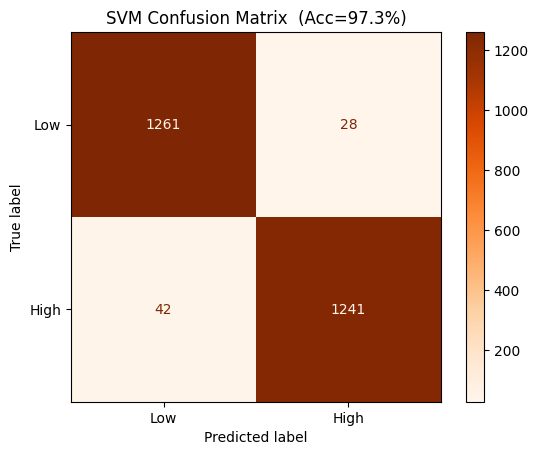

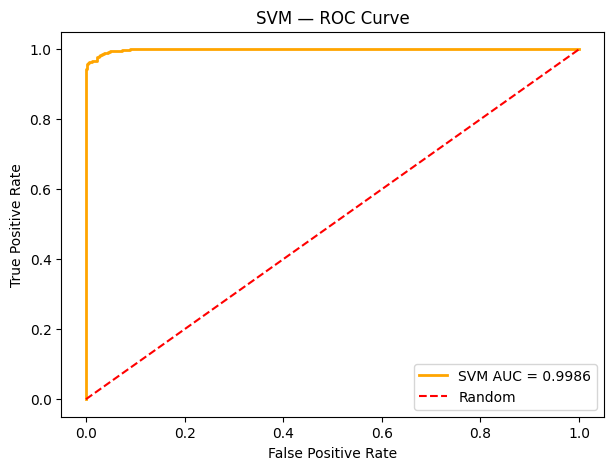

In [ ]:
from sklearn.svm import SVC

# ── Train ─────────────────────────────────────────────────────────────────────
svm_model = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
svm_model.fit(X_train2_s, y_train2)

# ── Predict ───────────────────────────────────────────────────────────────────
y_pred_svm = svm_model.predict(X_test2_s)
y_prob_svm = svm_model.predict_proba(X_test2_s)[:, 1]

# ── Metrics ───────────────────────────────────────────────────────────────────
acc_svm = accuracy_score(y_test2, y_pred_svm)
print(f"✅ SVM Accuracy: {acc_svm*100:.2f}%")
print()
print(classification_report(y_test2, y_pred_svm, target_names=['Low','High']))

# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm_svm = confusion_matrix(y_test2, y_pred_svm)
ConfusionMatrixDisplay(cm_svm, display_labels=['Low','High']).plot(cmap='Oranges')
plt.title(f'SVM Confusion Matrix  (Acc={acc_svm*100:.1f}%)')
plt.show()

# ── ROC Curve ─────────────────────────────────────────────────────────────────
fpr_svm, tpr_svm, _ = roc_curve(y_test2, y_prob_svm)
auc_svm = auc(fpr_svm, tpr_svm)

plt.figure(figsize=(7, 5))
plt.plot(fpr_svm, tpr_svm, color='orange', lw=2, label=f'SVM AUC = {auc_svm:.4f}')
plt.plot([0,1],[0,1],'r--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('SVM — ROC Curve')
plt.legend()
plt.show()

✅ Naive Bayes Accuracy: 97.32%

              precision    recall  f1-score   support

         Low       0.98      0.97      0.97      1289
        High       0.97      0.98      0.97      1283

    accuracy                           0.97      2572
   macro avg       0.97      0.97      0.97      2572
weighted avg       0.97      0.97      0.97      2572



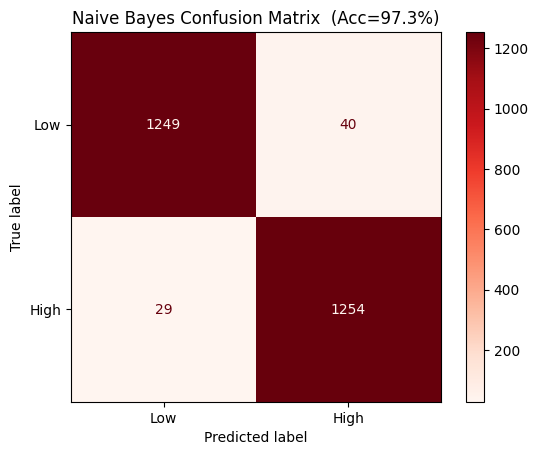

In [ ]:
from sklearn.naive_bayes import GaussianNB

# ── Train ─────────────────────────────────────────────────────────────────────
nb_model = GaussianNB()
nb_model.fit(X_train2_s, y_train2)

# ── Predict ───────────────────────────────────────────────────────────────────
y_pred_nb = nb_model.predict(X_test2_s)
y_prob_nb = nb_model.predict_proba(X_test2_s)[:, 1]

# ── Metrics ───────────────────────────────────────────────────────────────────
acc_nb = accuracy_score(y_test2, y_pred_nb)
print(f"✅ Naive Bayes Accuracy: {acc_nb*100:.2f}%")
print()
print(classification_report(y_test2, y_pred_nb, target_names=['Low','High']))

# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm_nb = confusion_matrix(y_test2, y_pred_nb)
ConfusionMatrixDisplay(cm_nb, display_labels=['Low','High']).plot(cmap='Reds')
plt.title(f'Naive Bayes Confusion Matrix  (Acc={acc_nb*100:.1f}%)')
plt.show()

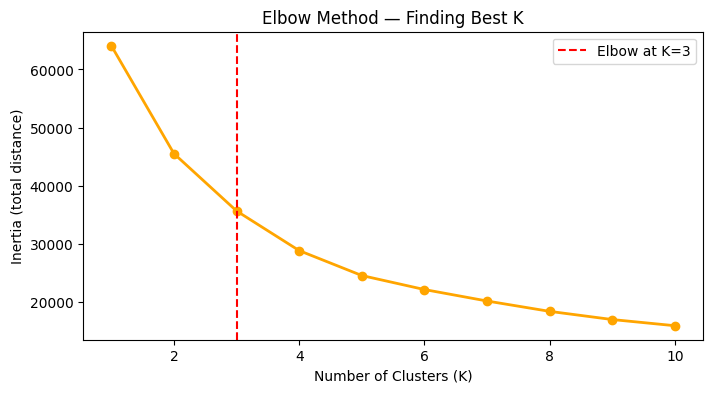

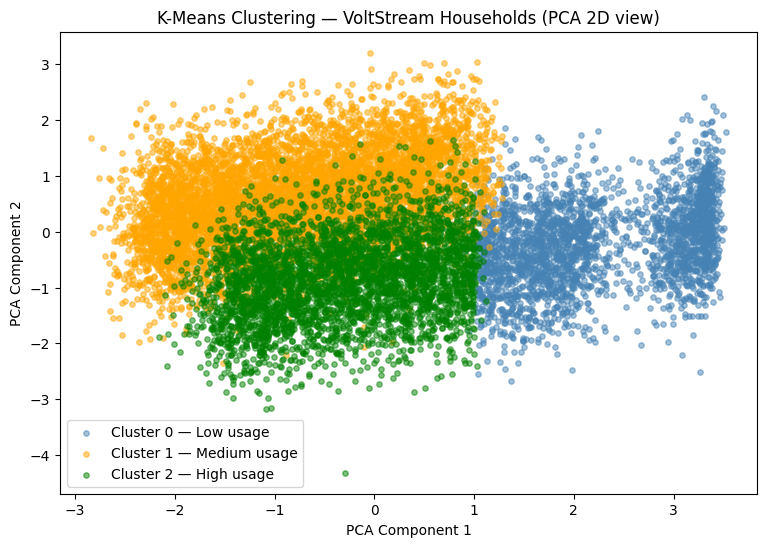

📊 Average stats per cluster:
         mean_consumption  household_size  mean_peak  has_ac
cluster                                                     
0                   18.03            5.19       8.12     1.0
1                    8.67            3.47       3.04     0.0
2                    8.50            2.28       3.83     1.0


In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# ── Elbow method to find best K ───────────────────────────────────────────────
inertias = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaler2.transform(X2))
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, marker='o', color='orange', lw=2)
plt.axvline(3, color='red', linestyle='--', label='Elbow at K=3')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (total distance)')
plt.title('Elbow Method — Finding Best K')
plt.legend()
plt.show()

# ── Train with K=3 ────────────────────────────────────────────────────────────
km_model = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = km_model.fit_predict(scaler2.transform(X2))
household['cluster'] = clusters

# ── Visualise clusters using PCA (reduce to 2D for plotting) ──────────────────
pca = PCA(n_components=2)
X_pca = pca.fit_transform(scaler2.transform(X2))

plt.figure(figsize=(9, 6))
colors = ['steelblue', 'orange', 'green']
labels = ['Cluster 0 — Low usage', 'Cluster 1 — Medium usage', 'Cluster 2 — High usage']

for i in range(3):
    mask = clusters == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors[i], label=labels[i], alpha=0.5, s=15)

plt.title('K-Means Clustering — VoltStream Households (PCA 2D view)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.show()

# ── Cluster profiles ──────────────────────────────────────────────────────────
print("📊 Average stats per cluster:")
print(household.groupby('cluster')[['mean_consumption','household_size',
                                     'mean_peak','has_ac']].mean().round(2))

          Algorithm  Accuracy (%)
      Random Forest     98.405910
      Decision Tree     98.367030
Logistic Regression     98.289269
                KNN     97.472784
        Naive Bayes     97.317263
                SVM     97.278383


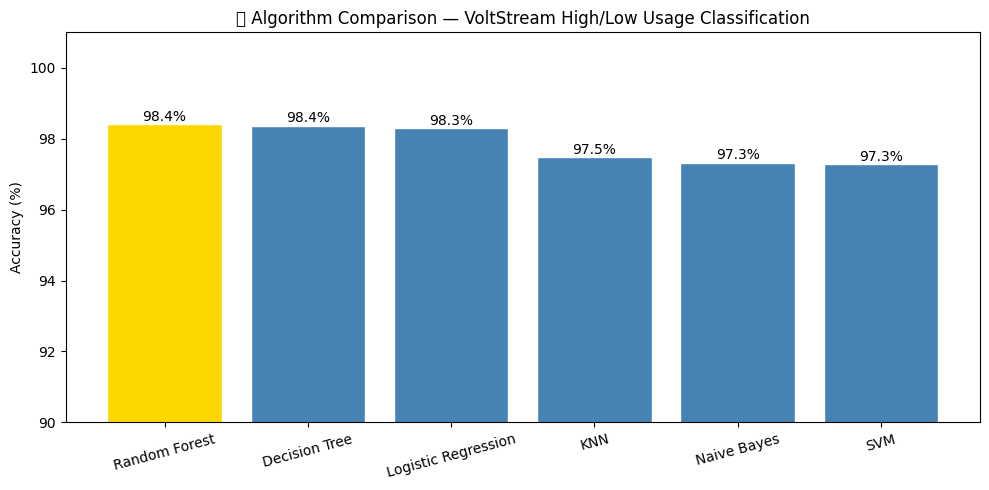

In [ ]:
# ── Compare all models ────────────────────────────────────────────────────────
results = pd.DataFrame({
    'Algorithm': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'KNN',
        'SVM',
        'Naive Bayes'
    ],
    'Accuracy (%)': [
        accuracy_score(y_test2, y_pred2)  * 100,
        accuracy_score(y_test2, y_pred_dt)* 100,
        accuracy_score(y_test2, y_pred_rf)* 100,
        accuracy_score(y_test2, y_pred_knn)*100,
        accuracy_score(y_test2, y_pred_svm)*100,
        accuracy_score(y_test2, y_pred_nb) * 100,
    ]
}).sort_values('Accuracy (%)', ascending=False).reset_index(drop=True)

print(results.to_string(index=False))

# ── Bar chart ─────────────────────────────────────────────────────────────────
colors = ['gold' if i == 0 else 'steelblue' for i in range(len(results))]
plt.figure(figsize=(10, 5))
bars = plt.bar(results['Algorithm'], results['Accuracy (%)'],
               color=colors, edgecolor='white')
plt.ylim(90, 101)
plt.ylabel('Accuracy (%)')
plt.title('🏆 Algorithm Comparison — VoltStream High/Low Usage Classification')
plt.xticks(rotation=15)

for bar, val in zip(bars, results['Accuracy (%)']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.1,
             f'{val:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

  Logistic Regression       Accuracy: 98.29%
  Decision Tree             Accuracy: 98.37%
  Random Forest             Accuracy: 98.41%
  KNN                       Accuracy: 97.71%
  SVM                       Accuracy: 97.28%
  Naive Bayes               Accuracy: 97.32%

🏆 Best Model : Random Forest  (98.41%)


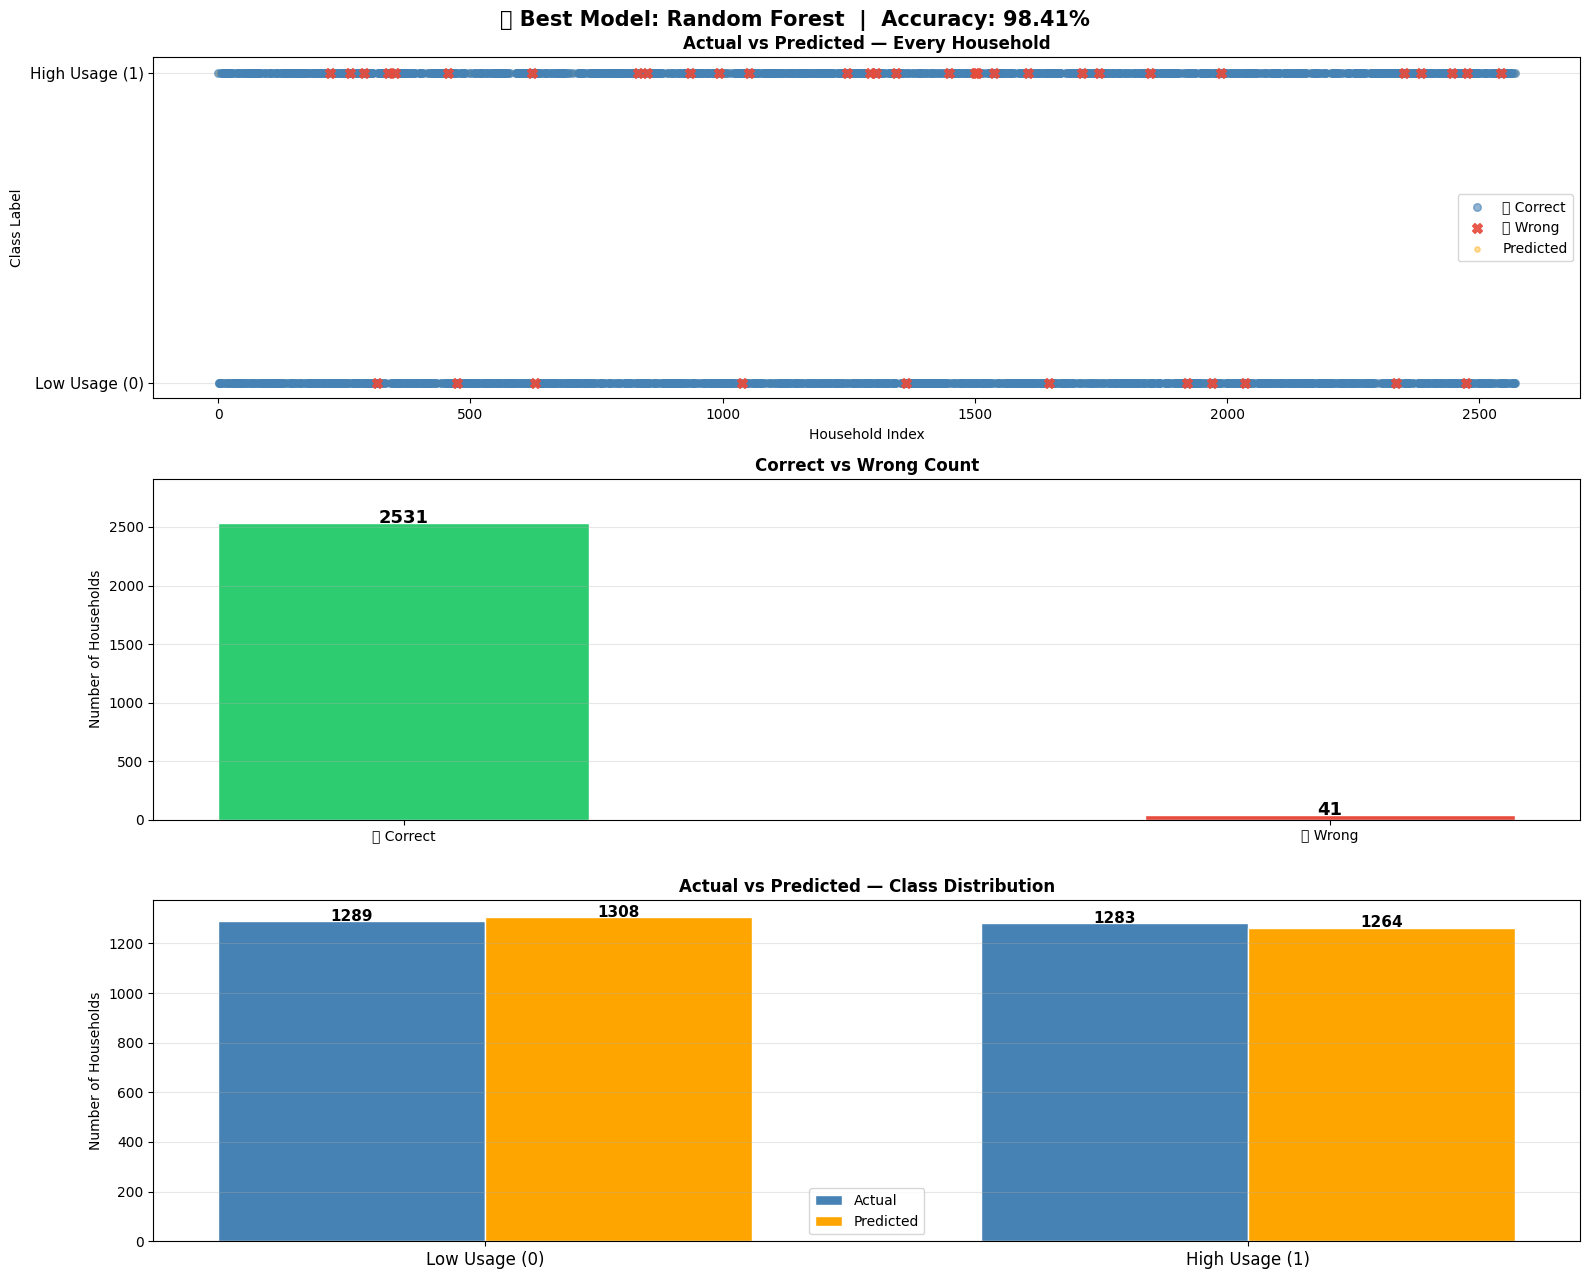


  🏆 Best Model  : Random Forest
  ✅ Correct     : 2531 / 2572  (98.4%)
  ❌ Wrong       : 41  / 2572  (1.6%)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score

# ── Recreate everything needed ────────────────────────────────────────────────
FEATURES = ['mean_temp', 'household_size', 'has_ac', 'mean_peak', 'std_consumption']

X2 = household[FEATURES]
y2 = household['high_usage']

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2)

scaler2 = StandardScaler()
X_train2_s = scaler2.fit_transform(X_train2)
X_test2_s  = scaler2.transform(X_test2)

# ── Train all 6 models ────────────────────────────────────────────────────────
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=4, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42),
    'KNN'                 : KNeighborsClassifier(n_neighbors=5),
    'SVM'                 : SVC(kernel='rbf', C=1.0, random_state=42),
    'Naive Bayes'         : GaussianNB(),
}

predictions = {}
accuracies  = {}

for name, model in models.items():
    model.fit(X_train2_s, y_train2)
    pred             = model.predict(X_test2_s)
    predictions[name] = pred
    accuracies[name]  = accuracy_score(y_test2, pred)
    print(f"  {name:<25} Accuracy: {accuracies[name]*100:.2f}%")

# ── Pick best model ───────────────────────────────────────────────────────────
best_name = max(accuracies, key=accuracies.get)
best_pred = predictions[best_name]
best_acc  = accuracies[best_name]

print(f"\n🏆 Best Model : {best_name}  ({best_acc*100:.2f}%)")

# ── Predicted vs Actual Plots ─────────────────────────────────────────────────
n         = len(y_test2)
x_indices = np.arange(n)
actual    = y_test2.values
predicted = best_pred
correct   = actual == predicted
wrong     = actual != predicted

fig, axes = plt.subplots(3, 1, figsize=(16, 13))
fig.suptitle(f'🏆 Best Model: {best_name}  |  Accuracy: {best_acc*100:.2f}%',
             fontsize=15, fontweight='bold')

# Plot 1: Dot plot
axes[0].scatter(x_indices[correct], actual[correct],
                color='steelblue', s=30, alpha=0.6, label='✅ Correct', zorder=3)
axes[0].scatter(x_indices[wrong], actual[wrong],
                color='#e74c3c', s=50, alpha=0.9, marker='X', label='❌ Wrong', zorder=4)
axes[0].scatter(x_indices, predicted,
                color='orange', s=15, alpha=0.4, label='Predicted', zorder=2)
axes[0].set_yticks([0, 1])
axes[0].set_yticklabels(['Low Usage (0)', 'High Usage (1)'], fontsize=11)
axes[0].set_xlabel('Household Index')
axes[0].set_ylabel('Class Label')
axes[0].set_title('Actual vs Predicted — Every Household', fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Correct vs Wrong count
n_correct = correct.sum()
n_wrong   = wrong.sum()
bars = axes[1].bar(['✅ Correct', '❌ Wrong'], [n_correct, n_wrong],
                    color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.4)
axes[1].set_title('Correct vs Wrong Count', fontweight='bold')
axes[1].set_ylabel('Number of Households')
for bar, val in zip(bars, [n_correct, n_wrong]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                  str(val), ha='center', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, max(n_correct, n_wrong) * 1.15)
axes[1].grid(axis='y', alpha=0.3)

# Plot 3: Class distribution comparison
categories       = ['Low Usage (0)', 'High Usage (1)']
actual_counts    = [np.sum(actual == 0),    np.sum(actual == 1)]
predicted_counts = [np.sum(predicted == 0), np.sum(predicted == 1)]
bar_width = 0.35
x_pos     = np.arange(2)

b1 = axes[2].bar(x_pos - bar_width/2, actual_counts,    bar_width,
                  label='Actual',    color='steelblue', edgecolor='white')
b2 = axes[2].bar(x_pos + bar_width/2, predicted_counts, bar_width,
                  label='Predicted', color='orange',    edgecolor='white')
axes[2].set_title('Actual vs Predicted — Class Distribution', fontweight='bold')
axes[2].set_ylabel('Number of Households')
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(categories, fontsize=12)
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)
for bar in list(b1) + list(b2):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                  str(int(bar.get_height())), ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n{'='*45}")
print(f"  🏆 Best Model  : {best_name}")
print(f"  ✅ Correct     : {n_correct} / {n}  ({n_correct/n*100:.1f}%)")
print(f"  ❌ Wrong       : {n_wrong}  / {n}  ({n_wrong/n*100:.1f}%)")
print(f"{'='*45}")